# 01 · Data Cleaning and Exploratory Data Analysis

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = "data"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

## 1. Load and audit the raw data

In [4]:
df = pd.read_csv(os.path.join(DATA_DIR, "aqi_master_updated.csv"))

print(df.shape)
print(df.columns.tolist())
df.info()
df.head()

(9116, 3)
['Date', 'AQI', 'City']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9116 entries, 0 to 9115
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    9116 non-null   object
 1   AQI     9116 non-null   int64 
 2   City    9116 non-null   object
dtypes: int64(1), object(2)
memory usage: 213.8+ KB


,Date,AQI,City
0,01-01-2019,118,Bengaluru
1,02-01-2019,92,Bengaluru
2,03-01-2019,93,Bengaluru
3,04-01-2019,104,Bengaluru
4,05-01-2019,102,Bengaluru


In [5]:
# Raw file uses DD-MM-YYYY
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())
print("Cities:", df['City'].nunique(), df['City'].unique())

Date range: 2019-01-01 to 2025-03-31
Cities: 4 ['Bengaluru' 'Delhi' 'Kolkata' 'Mumbai']


In [6]:
# Missing values and duplicates
print("Missing values per column:")
print(df.isnull().sum())

print("\nFully duplicated rows:", df.duplicated().sum())
print("Duplicated City-Date pairs:", df.duplicated(subset=['City', 'Date']).sum())

df = df.drop_duplicates(subset=['City', 'Date'])

Missing values per column:
Date     0
AQI      0
City     0
Month    0
Year     0
dtype: int64

Fully duplicated rows: 0
Duplicated City-Date pairs: 0


In [7]:
# Check for missing calendar dates
full_range = pd.date_range(df['Date'].min(), df['Date'].max(), freq='D')

missing_dates = {}
for city, g in df.groupby('City'):
    missing = full_range.difference(g['Date'])
    missing_dates[city] = [d.date() for d in missing]
    print(f"{city}: {len(missing)} missing days -> {missing_dates[city]}")

Bengaluru: 2 missing days -> [datetime.date(2020, 2, 29), datetime.date(2022, 7, 13)]
Delhi: 1 missing days -> [datetime.date(2020, 2, 29)]
Kolkata: 4 missing days -> [datetime.date(2019, 5, 13), datetime.date(2019, 5, 14), datetime.date(2020, 2, 29), datetime.date(2022, 7, 13)]
Mumbai: 5 missing days -> [datetime.date(2019, 2, 28), datetime.date(2019, 3, 1), datetime.date(2019, 4, 2), datetime.date(2020, 2, 29), datetime.date(2022, 7, 13)]


## 2. AQI categories (CPCB thresholds) and save the clean file

In [9]:
def compute_bucket(aqi):
    if aqi <= 50:    return 'Good'
    elif aqi <= 100: return 'Satisfactory'
    elif aqi <= 200: return 'Moderate'
    elif aqi <= 300: return 'Poor'
    elif aqi <= 400: return 'Very Poor'
    else:            return 'Severe'

df['AQI_Bucket'] = df['AQI'].apply(compute_bucket)

df = df.sort_values(['City', 'Date']).reset_index(drop=True)

# Saved with ISO dates (YYYY-MM-DD), so later notebooks do not need dayfirst=True
df.to_csv(os.path.join(DATA_DIR, "aqi_master_clean.csv"), index=False)
df.head()

,Date,AQI,City,Month,Year,AQI_Bucket
0,2019-01-01,118,Bengaluru,1,2019,Moderate
1,2019-01-02,92,Bengaluru,1,2019,Satisfactory
2,2019-01-03,93,Bengaluru,1,2019,Satisfactory
3,2019-01-04,104,Bengaluru,1,2019,Moderate
4,2019-01-05,102,Bengaluru,1,2019,Moderate


## 3. Summary statistics

In [11]:
summary_stats = df.groupby('City')['AQI'].describe().round(2)
summary_stats.to_csv(os.path.join(RESULTS_DIR, "summary_stats.csv"))
summary_stats

,count,mean,std,min,25%,50%,75%,max
City,,,,,,,,
Bengaluru,2280.0,74.08,25.43,24.0,54.0,69.0,91.0,172.0
Delhi,2281.0,206.08,104.65,41.0,116.0,191.0,284.0,494.0
Kolkata,2278.0,115.54,80.90,22.0,50.0,86.0,168.0,419.0
Mumbai,2277.0,107.34,55.88,25.0,61.0,92.0,146.0,381.0


## 4. Exploratory plots

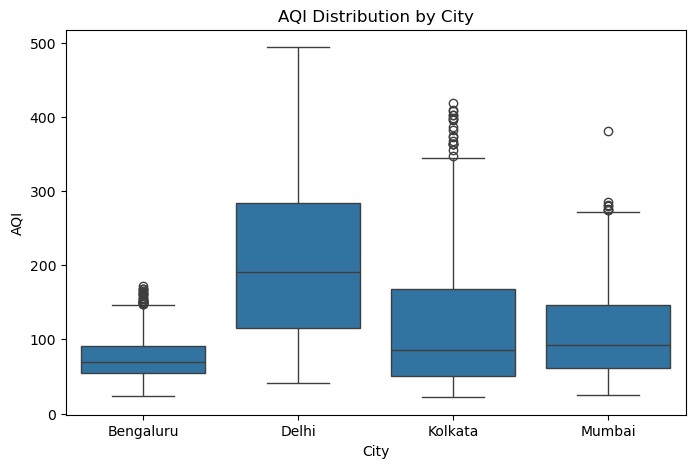

In [15]:
# PLOT 1: AQI distribution by city
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='City', y='AQI')
plt.title('AQI Distribution by City')
plt.show()

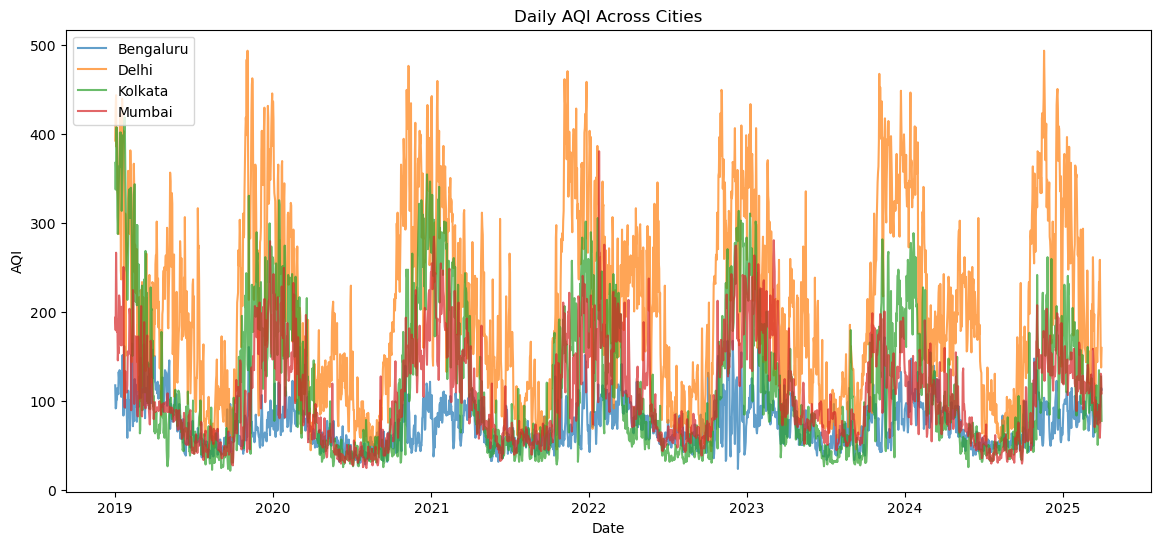

In [16]:
# PLOT 2: Daily AQI
plt.figure(figsize=(14, 6))
for city, g in df.groupby('City'):
    plt.plot(g['Date'], g['AQI'], label=city, alpha=0.7)
plt.title('Daily AQI Across Cities')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.show()

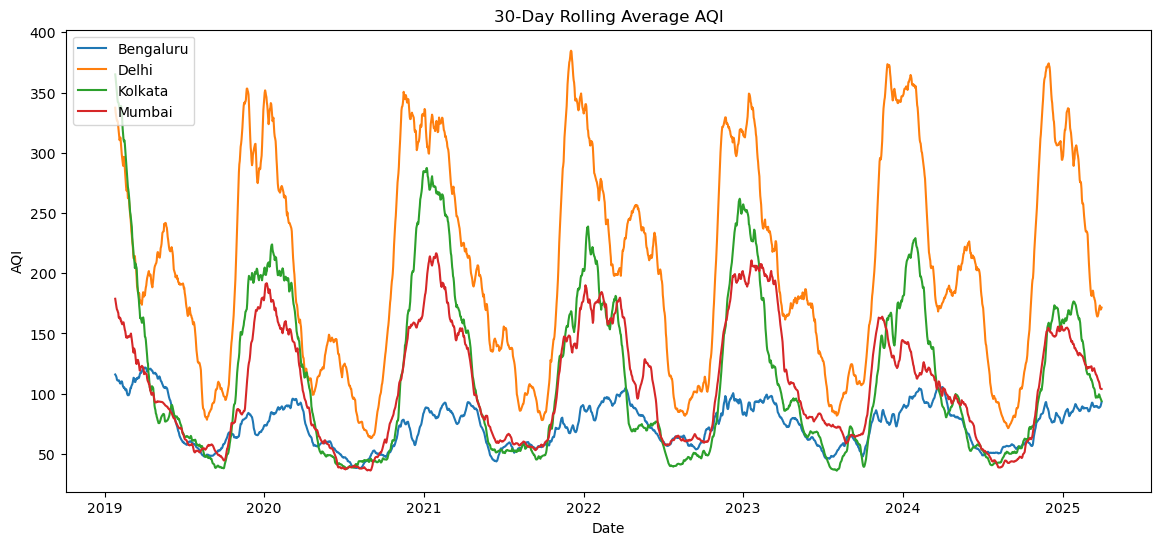

In [17]:
# PLOT 3: 30-day rolling average
# Time-based window ('30D') so missing days do not shift the window
plt.figure(figsize=(14, 6))
for city, g in df.groupby('City'):
    ma30 = g.set_index('Date')['AQI'].rolling('30D', min_periods=25).mean()
    plt.plot(ma30.index, ma30, label=city)
plt.title('30-Day Rolling Average AQI')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.show()

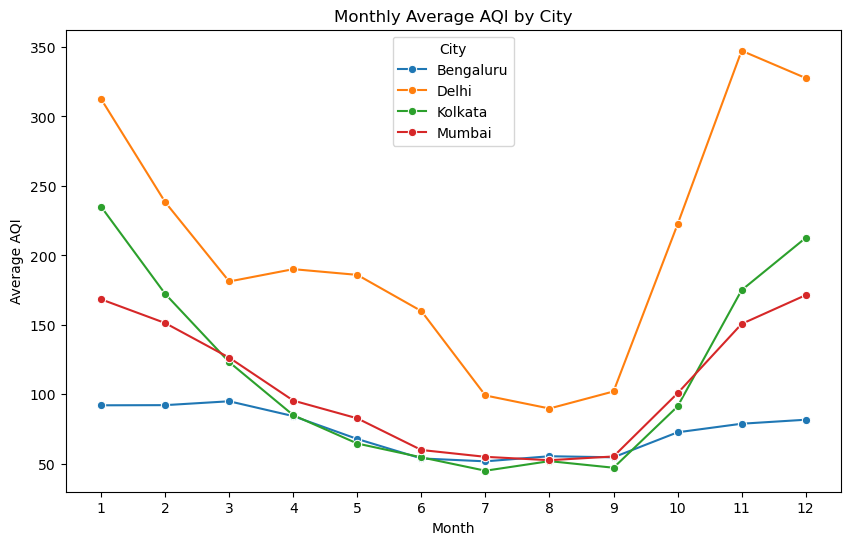

In [18]:
# PLOT 4: Average AQI by calendar month
monthly_avg = df.groupby(['City', 'Month'])['AQI'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_avg, x='Month', y='AQI', hue='City', marker='o')
plt.title('Monthly Average AQI by City')
plt.ylabel('Average AQI')
plt.xticks(range(1, 13))
plt.show()

Days per year: {2019: 365, 2020: 365, 2021: 365, 2022: 365, 2023: 365, 2024: 366, 2025: 90}
Complete years used: [2019, 2020, 2021, 2022, 2023, 2024]


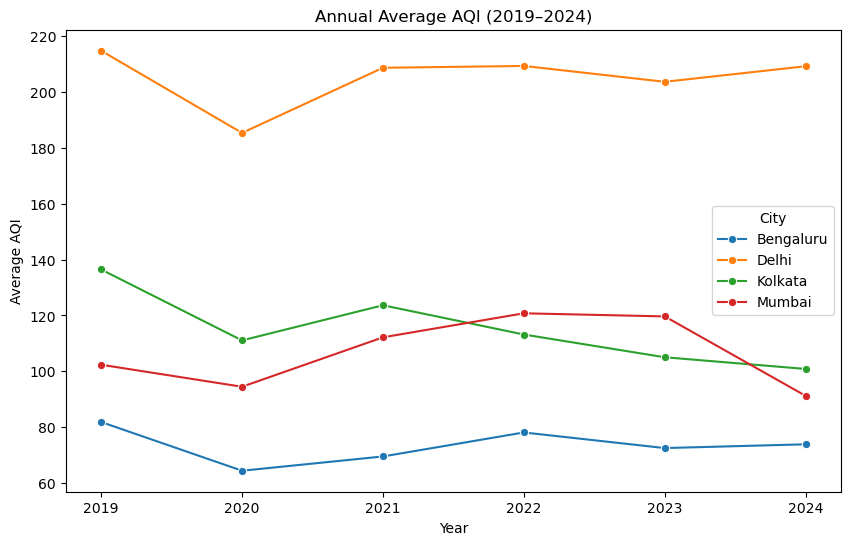

Year,2019,2020,2021,2022,2023,2024
City,,,,,,
Bengaluru,81.9,64.5,69.6,78.2,72.6,73.9
Delhi,214.7,185.3,208.6,209.2,203.6,209.1
Kolkata,136.4,111.1,123.6,113.2,105.1,100.9
Mumbai,102.4,94.5,112.2,120.8,119.7,91.2


In [19]:
# Annual averages use complete years only; 2025 contains only January–March
days_per_year = df.groupby('Year')['Date'].nunique()
complete_years = days_per_year[days_per_year >= 360].index.tolist()
print("Days per year:", days_per_year.to_dict())
print("Complete years used:", complete_years)

annual_avg = (
    df[df['Year'].isin(complete_years)]
      .groupby(['City', 'Year'])['AQI'].mean()
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=annual_avg, x='Year', y='AQI', hue='City', marker='o')
plt.title(f'Annual Average AQI ({min(complete_years)}–{max(complete_years)})')
plt.ylabel('Average AQI')
plt.xticks(complete_years)
plt.show()

display(annual_avg.pivot(index='City', columns='Year', values='AQI').round(1))